<a href="https://colab.research.google.com/github/DanielPrados/Simulacion-de-un-PAS/blob/main/GPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio: simular y visualizar GPs
Nuestro objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de machine learning (Python, Numpy, matplotlib). Como resultado final, generaremos algunas trayectorias asociadas.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utilizaremos la función `np.random.multivariate_normal`.

In [23]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.identity(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 0.31193333  1.36277107  0.45066203]
 [ 1.14496743  1.45978343  0.10271473]
 [ 0.22872216 -0.32635633 -1.79064301]
 [-0.78558426 -0.48636592  1.05434308]
 [ 0.50440772  0.65357423  0.87203189]
 [ 0.41388662  0.16766986  1.41718872]
 [-1.61792348  0.30589788 -0.92065564]
 [ 1.27338589  0.6829334   0.14054729]
 [-0.69563233 -0.58276933 -0.98129176]
 [-1.74854808 -0.98757213 -0.69996053]
 [ 0.92665897 -1.16235073  0.07422189]
 [-1.28359914  0.16149679  0.79535371]
 [-0.69021441 -0.07213871  0.7578498 ]
 [-0.47611122 -0.45741701  0.05384701]
 [ 1.57003152 -1.19647254  0.5713782 ]
 [-0.40499258  0.72138336  0.06985696]
 [-1.29493559  0.74347446  0.6141891 ]
 [ 0.23811297 -0.66928104 -0.92215119]
 [-0.31823286  1.95811644  0.82566769]
 [ 1.02423582  0.50410554  1.35239209]
 [-0.76078058 -0.96547941  0.38354864]
 [-0.09200425 -1.64577425 -1.65707248]
 [-0.75909134 -0.51451944  1.35001907]
 [-1.05793965 -0.11544628  0.84672106]
 [-1.4060619   0.53852757  2.11807403

Repitamos esto para una normal con matriz de covarianzas que no sea la identidad, por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

In [24]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 8.59615328e-01 -3.01423068e+00  2.61718019e+00]
 [ 6.59653603e-01  4.17890970e-01 -1.10910990e+01]
 [ 2.86038646e-01  3.69052850e+00  1.01621219e+01]
 [-1.03103671e+00  1.04169036e+00  6.23578071e+00]
 [-1.44584711e+00  1.95758155e+00  3.46934553e+00]
 [-1.93217840e+00  7.57285563e-01  1.29592090e+01]
 [-1.48323603e+00  2.24489877e+00 -1.66251871e+01]
 [-2.16616543e-01 -2.17000361e+00  8.94707466e-01]
 [-7.87171300e-01  2.16847354e-01 -2.76913199e+00]
 [-1.10733109e+00  1.28807180e+00 -1.05250247e+01]
 [-4.25627167e-01  4.52051641e+00  1.67837481e+01]
 [-7.65171002e-01 -1.88007180e+00  1.86081826e+01]
 [ 7.89364366e-02 -4.35034130e+00 -1.44875914e+01]
 [ 2.71122116e+00  6.93465647e+00  9.03746822e+00]
 [ 3.49396248e-01 -5.62635307e+00  1.07345587e+01]
 [ 9.03503403e-02  2.19639161e+00  1.12602229e+01]
 [ 1.46509636e+00 -7.07737694e+00  1.78812784e+01]
 [ 1.59897035e+00 -4.61969590e+00  1.17643869e+01]
 [-5.77066819e-02  2.63825665e+00 -1.85169030e+00]
 [-1

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular un GP con kernel RBF. Y la usaremos para generar imágenes asociadas a trayectorias con función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función).

Definimos la función principal:

In [2]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: Calculamos el vector de medias.
  vector_medias = np.zeros_like(t)

  # Paso 2: Calculamos la matriz de covarianzas.

  matriz_dist= t.reshape(len(t),1)-t.reshape(1,len(t))
  matriz_covs = sigma_sq**2*np.exp((-1/2*(matriz_dist/lengthscale)**2))

  # Paso 3: Obtenemos las muestras/simulaciones del GP.
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples


Ahora utilizamos esta función para generar trayectorias y las dibujaremos con `plt.plot`. Además, nos ayudaremos de `plt.subplots` para poder dibujar múltiples trayectorias en distintos ejes en una misma figura. En primer lugar, dibujaremos las trayectorias correspondientes al GP RBF con $\ell=1$ y $\sigma$ variante.

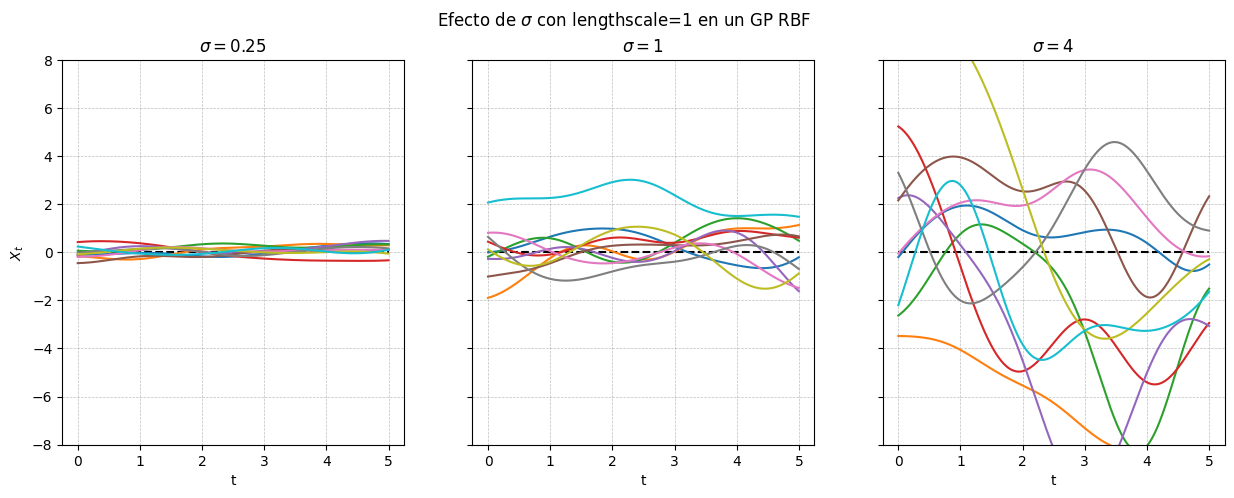

In [22]:
#Generamos un vector de puntos en el intervalo donde queremos representar las trayectorias.
t=np.linspace(0,5,500)
#Generamos las 3 muestras deseadas, variando sigma en cada una.
muestra1=simular_GP_RBF(t, sigma_sq=0.25, lengthscale=1,num_samples=10)
muestra2=simular_GP_RBF(t, sigma_sq=1, lengthscale=1,num_samples=10)
muestra3=simular_GP_RBF(t, sigma_sq=4, lengthscale=1,num_samples=10)
media=np.zeros_like(t)

#Preparamos la figura que vamos a imprimir, en este caso, como queremos dibujar 3 ejes en la misma figura nos ayudamos de los subplots.
fig, axes =plt.subplots(1, 3, figsize=(15,5),sharey=True)
fig.suptitle(r'Efecto de $\sigma$ con lengthscale=1 en un GP RBF')
#Utilizamos un for para los elementos que queremos que tengan en común todos los ejes
for ax in axes:
  ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
  ax.set_xlabel("t")
  ax.plot(t, media, color = 'black', linestyle = '--', linewidth = 1.5,alpha = 1)
#Posteriormente asignamos los valores concretos a cada eje uno a uno
axes[0].plot(t,np.transpose(muestra1))
axes[0].set_ylim(-8, 8)
axes[0].set_ylabel("$X_t$")
axes[0].set_title(r'$\sigma = 0.25$')

axes[1].plot(t,np.transpose(muestra2))
axes[1].set_title(r'$\sigma = 1$')

axes[2].plot(t,np.transpose(muestra3))
axes[2].set_title(r'$\sigma = 4$')

plt.show()

Ahora pasaremos a generar las trayectorias asociadas a un GP RBF con $\sigma=1$ y $\ell$ variante.

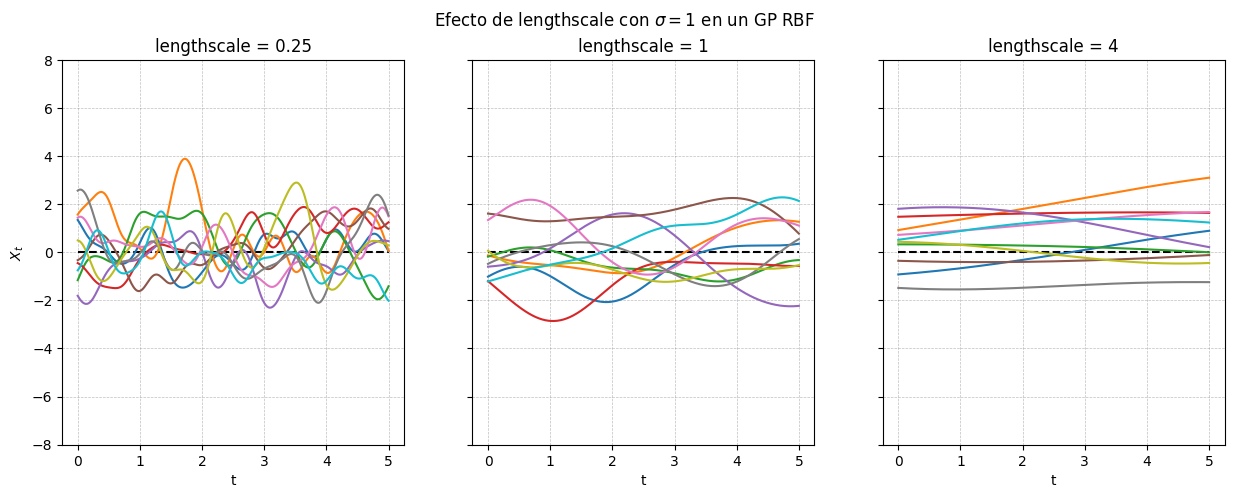

In [23]:
#Repetimos exactamente el mismo procedimiento anterior. En este caso en lugar de variar el valor de sigma, varía el valor de lengthscale.
muestra1=simular_GP_RBF(t, sigma_sq=1, lengthscale=0.25,num_samples=10)
muestra2=simular_GP_RBF(t, sigma_sq=1, lengthscale=1,num_samples=10)
muestra3=simular_GP_RBF(t, sigma_sq=1, lengthscale=4,num_samples=10)
media=np.zeros_like(t)

fig, axes=plt.subplots(1, 3, figsize=(15,5),sharey=True)
fig.suptitle(r'Efecto de lengthscale con $\sigma=1$ en un GP RBF')

for ax in axes:
  ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
  ax.set_xlabel("t")
  ax.plot(t, media, color = 'black', linestyle = '--', linewidth = 1.5,alpha = 1)

axes[0].plot(t,np.transpose(muestra1))
axes[0].set_ylim(-8, 8)
axes[0].set_ylabel("$X_t$")
axes[0].set_title(r'lengthscale = 0.25')

axes[1].plot(t,np.transpose(muestra2))
axes[1].set_title(r'lengthscale = 1')

axes[2].plot(t,np.transpose(muestra3))
axes[2].set_title(r'lengthscale = 4')

plt.show()

## 3. Simular un GP con kernel periódico

En esta sección definiremos una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes con trayectorias asociadas a este GP. Usaremos función de medias constantemente igual a cero.

In [16]:
def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, periodo=1, num_samples=1):

  """
  Simular un GP con kernel periódico.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.
  periodo: periodo asociado al kernel periódico

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: Calculamos el vector de medias.
  vector_medias = np.zeros_like(t)

  # Paso 2: Calculamos la matriz de covarianzas.

  matriz_dist= t.reshape(len(t),1)-t.reshape(1,len(t))
  matriz_covs = sigma_sq**2*np.exp(-(2/(lengthscale**2))*np.sin(np.pi*np.abs(matriz_dist)/periodo)**2)

  # Paso 3: Obtenemos las muestras/simulaciones del GP.
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)


  return samples

En primer lugar generaremos una figura con las trayectorias asociadas a un GP periódico con $\sigma=1$, periodo 1 y con $\ell$ variante.

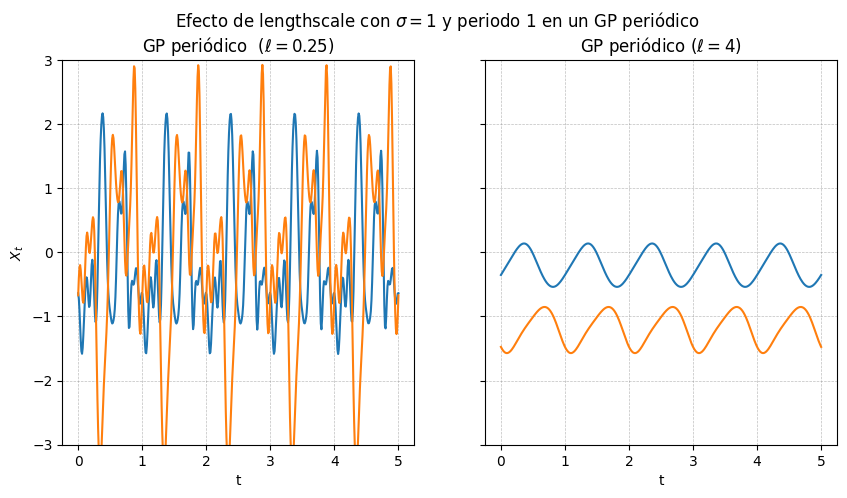

In [24]:
#Repetimos el proceso realizado en el caso del GP RBF pero usando la función anterior, en este caso dejaremos fijo sigma, el periodo y variará
#lengthscale.
muestra1=simular_GP_periodic(t, sigma_sq=1, lengthscale=0.25, periodo=1, num_samples=2)
muestra2=simular_GP_periodic(t, sigma_sq=1, lengthscale=4, periodo=1, num_samples=2)


fig,axes =plt.subplots(1, 2, figsize=(10,5),sharey=True)
fig.suptitle(r'Efecto de lengthscale con $\sigma=1$ y periodo 1 en un GP periódico')

for ax in axes:
  ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
  ax.set_xlabel("t")

axes[0].plot(t,np.transpose(muestra1))
axes[0].set_ylim(-3, 3)
axes[0].set_ylabel("$X_t$")
axes[0].set_title(r'GP periódico  $(\ell=0.25)$')

axes[1].plot(t,np.transpose(muestra2))
axes[1].set_title(r'GP periódico $(\ell=4)$')

plt.show()

Ahora vamos a generar una figura con las trayectorias asociadas a un GP periódico con $\sigma=1$, $\ell=1$ y con periodo variante.

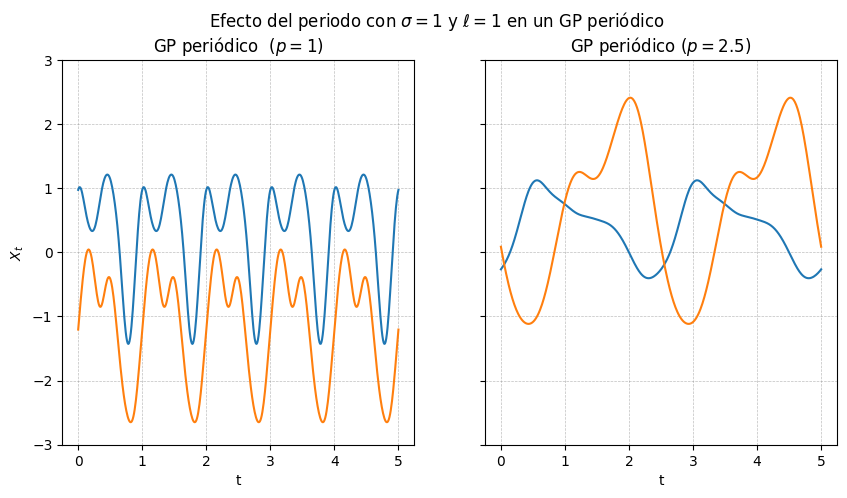

In [25]:
#Repetimos el procedimiento anterior, en este caso tomaremos una muestra con periodo 1 y otra con periodo 2.5.
muestra1=simular_GP_periodic(t, sigma_sq=1, lengthscale=1, periodo=1, num_samples=2)
muestra2=simular_GP_periodic(t, sigma_sq=1, lengthscale=1, periodo=2.5, num_samples=2)


fig, axes =plt.subplots(1, 2, figsize=(10,5),sharey=True)
fig.suptitle(r'Efecto del periodo con $\sigma=1$ y $\ell=1$ en un GP periódico')


for ax in axes:
  ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
  ax.set_xlabel("t")

axes[0].plot(t,np.transpose(muestra1))
axes[0].set_ylim(-3, 3)
axes[0].set_ylabel("$X_t$")
axes[0].set_title(r'GP periódico  $(p=1)$')

axes[1].plot(t,np.transpose(muestra2))
axes[1].set_title(r'GP periódico $(p=2.5)$')

plt.show()

Por último, dibujaremos el GP periódico con periodo constantemente 1, $\ell=1$ y $\sigma$ variante.

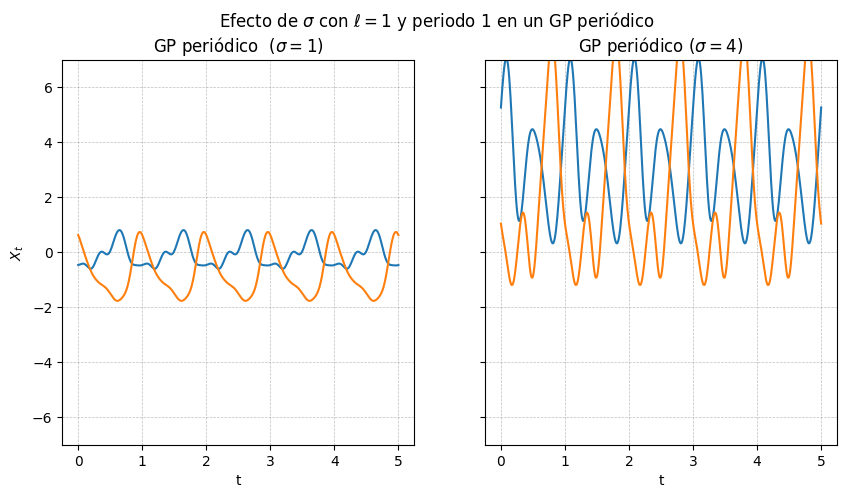

In [26]:
#De nuevo repetimos el procedimiento considerando las muestras para los valores de sigma=1 y sigma=4.
muestra1=simular_GP_periodic(t, sigma_sq=1, lengthscale=1, periodo=1, num_samples=2)
muestra2=simular_GP_periodic(t, sigma_sq=4, lengthscale=1, periodo=1, num_samples=2)


fig, axes =plt.subplots(1, 2, figsize=(10,5),sharey=True)
fig.suptitle(r'Efecto de $\sigma$ con $\ell=1$ y periodo 1 en un GP periódico')


for ax in axes:
  ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
  ax.set_xlabel("t")

axes[0].plot(t,np.transpose(muestra1))
axes[0].set_ylim(-7, 7)
axes[0].set_ylabel("$X_t$")
axes[0].set_title(r'GP periódico  $(\sigma=1)$')

axes[1].plot(t,np.transpose(muestra2))
axes[1].set_title(r'GP periódico $(\sigma=4)$')

plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección definiremos una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, consideraremos un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usaremos para generar imágenes similares a las de las diapositivas. De nuevo utilizaremos función de medias constantemente igual a cero.

In [20]:
def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK con funciones base 1, t, ..., t^m.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo de los monomios utilizados. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """

    # Paso 1: Calculamos el vector de medias.
    vector_medias = np.zeros_like(t)

    # Paso 2: Calculamos la matriz de covarianzas utilizando el producto matricial F*F^T.
    matrizF = np.vander(t, m+1, increasing= True)
    matriz_covs = matrizF @ np.transpose(matrizF)
    #Añadimos un ruido definido positivo para evitar problemas numéricos de redondeo.
    matriz_covs = matriz_covs + 1e-9 * np.eye(len(t))

    # Paso 3: Obtenemos las muestras/simulaciones del GP
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

A continuación, utilizaremos la función previamente definida para generar una imagen con las trayectorias asociadas a un GP DPK con funciones base $1,t,t^2,\ldots,t^m$ para $m=1,\; m=2 \text{ y } m=3$.

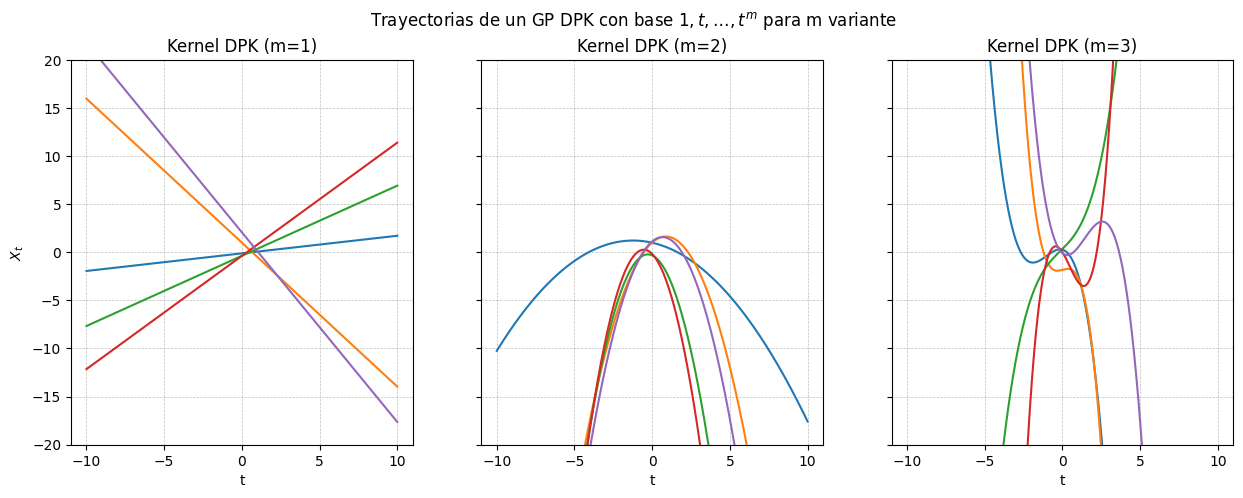

In [28]:
#En primer lugar generamos un vector de puntos en el que queremos evaluar el GP.
t=np.linspace(-10, 10, 500)
#A continuación, generamos las respectivas muestras
muestra1=simular_GP_DPKpoly(t, m=1, num_samples=5)
muestra2=simular_GP_DPKpoly(t, m=2, num_samples=5)
muestra3=simular_GP_DPKpoly(t, m=3, num_samples=5)
#Por último, generamos la figura que contenga las trayectorias asociadas a cada m.
fig, axes = plt.subplots(1, 3, figsize=(15,5),sharey=True)
fig.suptitle(r'Trayectorias de un GP DPK con base $1,t,\ldots,t^m$ para m variante')


for ax in axes:
  ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
  ax.set_xlabel("t")

axes[0].plot(t,np.transpose(muestra1))
axes[0].set_ylim(-20, 20)
axes[0].set_ylabel("$X_t$")
axes[0].set_title(r'Kernel DPK (m=1)')

axes[1].plot(t,np.transpose(muestra2))
axes[1].set_title(r'Kernel DPK (m=2)')

axes[2].plot(t,np.transpose(muestra3))
axes[2].set_title(r'Kernel DPK (m=3)')

plt.show()

## 5. ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

En esta sección se presenta brevemente una solución basada en la programación orientada a objetos (POO).

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ''parecido'' a un _struct_, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [29]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [31]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))
# Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)
# Aquí utilizamos el método __call__
print(cov_mat.shape)
# Deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


A continuación definimos una clase para la función de medias constantemente igual a cero:

In [32]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [33]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Definimos ahora una función ```simular_GP``` que recibe como parámetros cualquier función de medias (```mf```) y cualquier kernel (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [34]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para probar esta función, vamos a generar una imagen asociada a un kernel RBF, con función de medias identidad.

Para ello, definimos una clase para la función de medias identidad:

In [35]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

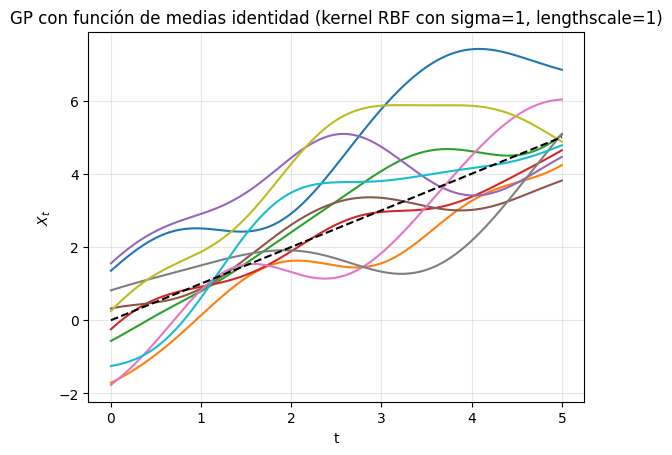

In [37]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP con función de medias identidad (kernel RBF con sigma={sigma}, lengthscale={lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()